# 06 — Baseline Experiment (Phase 0)
This notebook runs the baseline configuration `n_runs=10` replicates,
aggregates metrics (mean ± std) and plots time-series with shaded std bands.

In [6]:
# Setup imports and ensure `backend` is on sys.path so notebooks import from sim package
from pathlib import Path
import sys
project_root = Path.cwd().parent
# Make both `sim` and `backend` importable from notebooks (robust for different run contexts)
sys.path.insert(0, str(project_root))
sys.path.insert(0, str(project_root / 'backend'))

import json
import matplotlib.pyplot as plt
import numpy as np

# Import simulation helpers
from sim.simulation import DEFAULT_CONFIG, run_replicated

# Notebook plotting defaults
plt.style.use('seaborn-v0_8')
%matplotlib inline

In [7]:
# Configure baseline and run replicates
config = dict(DEFAULT_CONFIG)
config['N'] = 200
config['T'] = 200
config['snapshot_interval'] = 6
config['seed'] = 42
n_runs = 10

print('Running', n_runs, 'replicates with config:')
print({k: config[k] for k in ['N','T','snapshot_interval','alpha','beta_pop']})

result = run_replicated(config, n_runs=n_runs)
aggregated = result['aggregated']

Running 10 replicates with config:
{'N': 200, 'T': 200, 'snapshot_interval': 6, 'alpha': 0.65, 'beta_pop': 0.2}


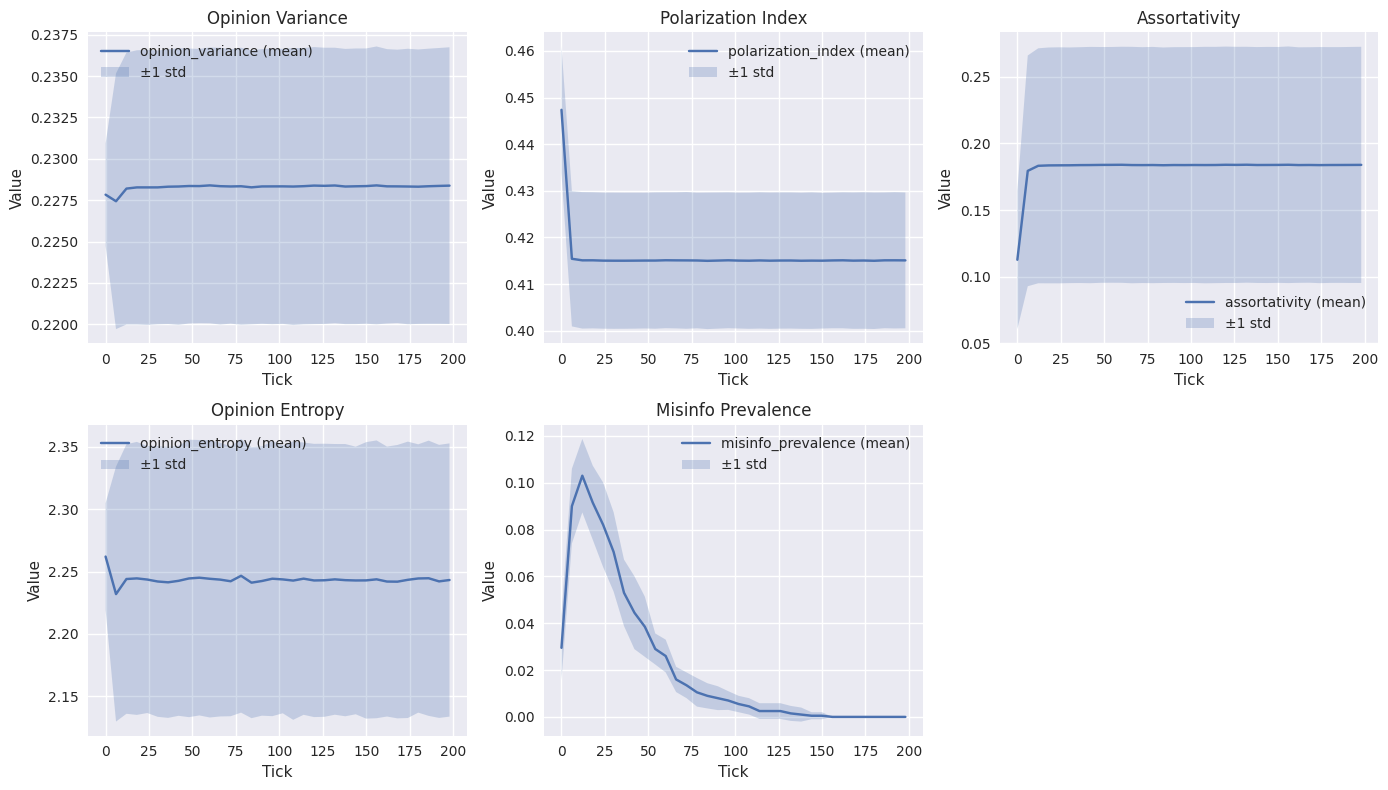

In [8]:
# Plot mean ± std for the primary metrics defined in the implementation plan
ticks = aggregated.get('tick', [])
metrics = ['opinion_variance', 'polarization_index', 'assortativity', 'opinion_entropy', 'misinfo_prevalence']
n_metrics = len(metrics)
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
for i, metric in enumerate(metrics):
    mean_series = np.array(aggregated.get(f"{metric}_mean", []))
    std_series = np.array(aggregated.get(f"{metric}_std", []))
    ax = axes[i]
    if mean_series.size == 0:
        ax.text(0.5, 0.5, 'No data', ha='center')
        continue
    ax.plot(ticks, mean_series, label=f'{metric} (mean)')
    ax.fill_between(ticks, mean_series - std_series, mean_series + std_series, alpha=0.25, label='±1 std')
    ax.set_title(metric.replace('_',' ').title())
    ax.set_xlabel('Tick')
    ax.set_ylabel('Value')
    ax.legend()

# Hide unused subplot if present
if n_metrics < len(axes):
    for j in range(n_metrics, len(axes)):
        fig.delaxes(axes[j])

fig.tight_layout()
plt.show()

In [9]:
# Simple stability checks: std < 0.1 * mean for each metric where mean > 0
stability = {}
for metric in metrics:
    mean_series = np.array(aggregated.get(f"{metric}_mean", []))
    std_series = np.array(aggregated.get(f"{metric}_std", []))
    if mean_series.size == 0:
        stability[metric] = 'no data'
        continue
    final_mean = float(mean_series[-1])
    final_std = float(std_series[-1]) if std_series.size else 0.0
    ratio = abs(final_std) / max(1e-12, abs(final_mean)) if abs(final_mean) > 0 else float('inf')
    stability[metric] = {'final_mean': final_mean, 'final_std': final_std, 'std_over_mean': ratio, 'stable': ratio < 0.1}

import pprint
pprint.pprint(stability)

{'assortativity': {'final_mean': 0.18392680724318466,
                   'final_std': 0.08871721824827604,
                   'stable': False,
                   'std_over_mean': 0.4823506675183882},
 'misinfo_prevalence': {'final_mean': 0.0,
                        'final_std': 0.0,
                        'stable': False,
                        'std_over_mean': inf},
 'opinion_entropy': {'final_mean': 2.2431916155533473,
                     'final_std': 0.10962180883860911,
                     'stable': True,
                     'std_over_mean': 0.04886867803826369},
 'opinion_variance': {'final_mean': 0.2283824592009685,
                      'final_std': 0.00836083261149492,
                      'stable': True,
                      'std_over_mean': 0.036608908760973106},
 'polarization_index': {'final_mean': 0.41509390006926566,
                        'final_std': 0.014556751809621574,
                        'stable': True,
                        'std_over_mean': 0.0350685

In [10]:
# Save the full replicated result to results/ for later analysis
from pathlib import Path
out_dir = Path('results')
out_dir.mkdir(exist_ok=True)
out_file = out_dir / 'baseline_replicated.json'
with open(out_file, 'wb') as f:
    f.write(json.dumps(result, default=lambda o: o, indent=2).encode('utf-8'))

print('Wrote', out_file)

Wrote results/baseline_replicated.json
